# Project 11 — Multimodal Fake News Detection
## Notebook 2: Image Download & Preparation

**MS1 objective:** create a reproducible image pipeline for the image+text dataset.

This notebook prepares the visual modality required by the project by extracting article images from `news_url`, validating downloaded images, rebuilding image manifests, and creating unified `*_multimodal.csv` files for model training.

**Why this matters for image--text inconsistency:** the model cannot learn cross-modal inconsistency unless each article has a clean text input and a corresponding image path or an explicit missing-image placeholder.


## MS1 Checklist Covered

- Data pipeline for **image + text** inputs.
- Image validation, filtering, and reproducible file organization.
- Image manifest files that connect article IDs to image paths.
- Coverage statistics for reporting image availability.
- Output files consumed by the text-only baseline and multimodal fusion model.


---
## 1 · Setup, Imports, and Reproducibility


In [32]:
# Optional install command, run only if the environment is missing packages:
# !pip install pandas numpy matplotlib seaborn requests beautifulsoup4 Pillow tqdm lxml --quiet

import os
import re
import json
import time
import hashlib
import random
import warnings
from pathlib import Path
from urllib.parse import urljoin, urlparse
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from PIL import Image, UnidentifiedImageError
from bs4 import BeautifulSoup
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Imports successful.')


Imports successful.


In [33]:
# Configuration
SPLITS = ['train', 'val', 'test']
DATA_SPLIT_DIR = Path('data_splits')
IMAGE_DIR = Path('images')
MANIFEST_DIR = Path('image_manifests')

# Set True only when you are ready to download images from the web.
# For reproducible grading, the notebook can still rebuild manifests from existing images when False.
RUN_DOWNLOAD = True
MAX_IMAGES_PER_ARTICLE = 3
MIN_IMAGE_SIZE = (100, 100)
MAX_IMAGE_SIZE = (2000, 2000)
TIMEOUT = 10
SLEEP_BETWEEN_REQUESTS = 0.05
ALLOWED_FORMATS = {'JPEG', 'PNG', 'WEBP', 'BMP'}

for split in SPLITS:
    (IMAGE_DIR / split).mkdir(parents=True, exist_ok=True)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

print(f'DATA_SPLIT_DIR: {DATA_SPLIT_DIR.resolve()}')
print(f'IMAGE_DIR     : {IMAGE_DIR.resolve()}')
print(f'MANIFEST_DIR  : {MANIFEST_DIR.resolve()}')
print(f'RUN_DOWNLOAD  : {RUN_DOWNLOAD}')


DATA_SPLIT_DIR: D:\DL\Project\Deep-learning-Multimodal\data_splits
IMAGE_DIR     : D:\DL\Project\Deep-learning-Multimodal\images
MANIFEST_DIR  : D:\DL\Project\Deep-learning-Multimodal\image_manifests
RUN_DOWNLOAD  : True


---
## 2 · Load Balanced Train/Validation/Test Splits


In [34]:
def load_split(split_name: str) -> pd.DataFrame:
    path = DATA_SPLIT_DIR / f'{split_name}.csv'
    if not path.exists():
        raise FileNotFoundError(
            f'Missing {path}. Run Notebook 01 first to create the balanced splits.'
        )
    df = pd.read_csv(path)
    required = {'id', 'title', 'label', 'source'}
    missing_required = required - set(df.columns)
    if missing_required:
        raise ValueError(f'{path} is missing required columns: {missing_required}')
    if 'news_url' not in df.columns:
        df['news_url'] = np.nan
    return df

splits_data = {split: load_split(split) for split in SPLITS}
for split, df in splits_data.items():
    print(f'{split:5s}: {len(df):4d} rows | labels: {df["label"].value_counts().to_dict()} | missing URLs: {df["news_url"].isna().sum()}')


train: 8843 rows | labels: {'real': 4498, 'fake': 4345} | missing URLs: 245
val  : 1105 rows | labels: {'real': 562, 'fake': 543} | missing URLs: 24
test : 1106 rows | labels: {'real': 562, 'fake': 544} | missing URLs: 31


---
## 3 · Image Extraction and Validation Functions


In [35]:
def normalize_url(url: str) -> str:
    """Return a normalized URL with a scheme, or an empty string for invalid input."""
    if not isinstance(url, str) or not url.strip():
        return ''
    url = url.strip()
    if not url.startswith(('http://', 'https://')):
        url = 'https://' + url
    return url


def parse_srcset(srcset: str):
    """Extract candidate URLs from an HTML srcset string."""
    if not isinstance(srcset, str):
        return []
    return [part.strip().split(' ')[0] for part in srcset.split(',') if part.strip()]


def extract_images_from_url(url: str, max_images: int = 3, timeout: int = 10) -> list:
    """Extract image URLs from an article page using meta tags and image tags.

    Returns a list of dictionaries containing `image_url` and `source_type`.
    """
    url = normalize_url(url)
    if not url:
        return []

    headers = {'User-Agent': 'Mozilla/5.0 (compatible; MS1FakeNewsProject/1.0)'}
    try:
        response = requests.get(url, timeout=timeout, headers=headers)
        response.raise_for_status()
        soup = BeautifulSoup(response.content, 'html.parser')
    except Exception:
        return []

    candidates = []

    # High-quality article image hints
    meta_selectors = [
        ('meta', {'property': 'og:image'}, 'og:image'),
        ('meta', {'name': 'twitter:image'}, 'twitter:image'),
        ('meta', {'property': 'twitter:image'}, 'twitter:image'),
    ]
    for tag_name, attrs, source_type in meta_selectors:
        tag = soup.find(tag_name, attrs=attrs)
        if tag and tag.get('content'):
            candidates.append((urljoin(url, tag['content']), source_type))

    # General image tags, including lazy-loaded attributes
    for img_tag in soup.find_all('img'):
        for attr in ['src', 'data-src', 'data-original', 'data-lazy-src']:
            src = img_tag.get(attr)
            if src:
                candidates.append((urljoin(url, src), f'img:{attr}'))
        for src in parse_srcset(img_tag.get('srcset')):
            candidates.append((urljoin(url, src), 'img:srcset'))

    # De-duplicate while preserving order
    seen = set()
    unique = []
    for image_url, source_type in candidates:
        if image_url not in seen and image_url.startswith(('http://', 'https://')):
            seen.add(image_url)
            unique.append({'image_url': image_url, 'source_type': source_type})
    return unique[:max_images]


def download_and_validate_image(img_url: str, timeout: int = 10):
    """Download and validate one image. Returns (PIL image, metadata) or (None, reason)."""
    headers = {'User-Agent': 'Mozilla/5.0 (compatible; MS1FakeNewsProject/1.0)'}
    try:
        response = requests.get(img_url, timeout=timeout, headers=headers)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content))
        img.verify()  # integrity check
        img = Image.open(BytesIO(response.content)).convert('RGB')
    except (requests.RequestException, UnidentifiedImageError, OSError, ValueError) as exc:
        return None, {'error': type(exc).__name__}

    original_size = img.size
    fmt = (img.format or 'UNKNOWN').upper()
    if fmt not in ALLOWED_FORMATS and fmt != 'UNKNOWN':
        return None, {'error': f'unsupported_format:{fmt}', 'original_size': original_size}

    w, h = img.size
    if w < MIN_IMAGE_SIZE[0] or h < MIN_IMAGE_SIZE[1]:
        return None, {'error': 'too_small', 'original_size': original_size}

    if w > MAX_IMAGE_SIZE[0] or h > MAX_IMAGE_SIZE[1]:
        img.thumbnail(MAX_IMAGE_SIZE, Image.Resampling.LANCZOS)

    return img, {'error': None, 'original_size': original_size, 'final_size': img.size}

print('Image extraction and validation functions are ready.')


Image extraction and validation functions are ready.


---
## 4 · Optional Web Download Step


In [ ]:
def save_download_manifest(records, split_name: str):
    """Save image metadata records for a split."""
    df_records = pd.DataFrame(records)
    out_path = MANIFEST_DIR / f'{split_name}_download_manifest.csv'
    df_records.to_csv(out_path, index=False)
    return out_path

all_download_records = {split: [] for split in SPLITS}

def run_download_for_split(split_name: str, df: pd.DataFrame):
    records = []
    split_dir = IMAGE_DIR / split_name
    stats = {'articles': len(df), 'articles_with_image': 0, 'images_saved': 0, 'failed_articles': 0}

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f'download:{split_name}'):
        article_id = str(row['id'])
        url = row.get('news_url', '')
        image_candidates = extract_images_from_url(url, max_images=MAX_IMAGES_PER_ARTICLE, timeout=TIMEOUT)

        saved_for_article = 0
        for img_idx, item in enumerate(image_candidates):
            img, meta = download_and_validate_image(item['image_url'], timeout=TIMEOUT)
            if img is None:
                records.append({
                    'article_id': article_id,
                    'label': row['label'],
                    'source': row['source'],
                    'image_url': item['image_url'],
                    'source_type': item['source_type'],
                    'download_status': meta.get('error', 'failed'),
                    'image_path': None,
                    'image_index': img_idx,
                })
                continue

            img_hash = hashlib.md5(item['image_url'].encode('utf-8')).hexdigest()[:10]
            filename = f'{article_id}_{img_idx}_{img_hash}.jpg'
            image_path = split_dir / filename
            img.save(image_path, 'JPEG', quality=90)

            records.append({
                'article_id': article_id,
                'label': row['label'],
                'source': row['source'],
                'image_url': item['image_url'],
                'source_type': item['source_type'],
                'download_status': 'ok',
                'image_path': str(image_path),
                'image_index': img_idx,
                'original_size': meta.get('original_size'),
                'final_size': meta.get('final_size'),
            })
            stats['images_saved'] += 1
            saved_for_article += 1

        if saved_for_article > 0:
            stats['articles_with_image'] += 1
        else:
            stats['failed_articles'] += 1

        time.sleep(SLEEP_BETWEEN_REQUESTS)

    manifest_path = save_download_manifest(records, split_name)
    return stats, manifest_path

if RUN_DOWNLOAD:
    download_stats = {}
    for split_name, df in splits_data.items():
        stats, manifest_path = run_download_for_split(split_name, df)
        download_stats[split_name] = stats
        print(split_name, stats, 'saved:', manifest_path)
else:
    print('RUN_DOWNLOAD=False, so the notebook will use existing files in images/<split>/ if available.')


download:train:  15%|█▌        | 1346/8843 [56:18<6:28:49,  3.11s/it]

---
## 5 · Rebuild Image Manifests from Disk


In [ ]:
def rebuild_manifest_from_disk(split_name: str, df: pd.DataFrame) -> pd.DataFrame:
    """Scan images/<split>/ and create one row per saved image."""
    split_dir = IMAGE_DIR / split_name
    id_to_meta = {str(row['id']): {'label': row['label'], 'source': row['source']} for _, row in df.iterrows()}
    records = []

    for image_path in sorted(split_dir.glob('*')):
        if image_path.suffix.lower() not in ['.jpg', '.jpeg', '.png', '.webp', '.bmp']:
            continue
        parts = image_path.name.rsplit('_', 2)
        article_id = parts[0] if len(parts) >= 3 else image_path.stem
        try:
            with Image.open(image_path) as img:
                width, height = img.size
        except Exception:
            width, height = None, None

        records.append({
            'article_id': str(article_id),
            'label': id_to_meta.get(str(article_id), {}).get('label'),
            'source': id_to_meta.get(str(article_id), {}).get('source'),
            'image_filename': image_path.name,
            'image_path': str(image_path),
            'image_ext': image_path.suffix.lower(),
            'width': width,
            'height': height,
        })

    manifest = pd.DataFrame(records)
    csv_path = MANIFEST_DIR / f'{split_name}_image_manifest.csv'
    json_path = MANIFEST_DIR / f'{split_name}_image_manifest.json'
    manifest.to_csv(csv_path, index=False)

    grouped = []
    if not manifest.empty:
        for article_id, grp in manifest.groupby('article_id'):
            grouped.append({'article_id': article_id, 'n_images': len(grp), 'image_paths': grp['image_path'].tolist()})
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(grouped, f, indent=2)

    print(f'{split_name}: saved {len(manifest)} image rows -> {csv_path}')
    return manifest

manifests = {split: rebuild_manifest_from_disk(split, df) for split, df in splits_data.items()}


train: saved 0 image rows -> image_manifests\train_image_manifest.csv
val: saved 0 image rows -> image_manifests\val_image_manifest.csv
test: saved 0 image rows -> image_manifests\test_image_manifest.csv


---
## 6 · Create Unified Multimodal CSV Files


In [ ]:
def create_multimodal_split(split_name: str, df: pd.DataFrame, manifest: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if not manifest.empty:
        article_to_images = manifest.groupby('article_id')['image_path'].apply(list).to_dict()
    else:
        article_to_images = {}

    out['id'] = out['id'].astype(str)
    out['has_image'] = out['id'].isin(article_to_images)
    out['image_path_primary'] = out['id'].map(lambda x: article_to_images.get(x, [np.nan])[0])
    out['image_paths'] = out['id'].map(lambda x: ';'.join(article_to_images.get(x, [])))
    out['n_images_downloaded'] = out['id'].map(lambda x: len(article_to_images.get(x, [])))
    out['usable_text'] = out['title'].notna() & out['title'].astype(str).str.strip().ne('')
    out['usable_image'] = out['has_image']
    out['usable_both'] = out['usable_text'] & out['usable_image']

    output_path = DATA_SPLIT_DIR / f'{split_name}_multimodal.csv'
    out.to_csv(output_path, index=False)
    return out, output_path

multimodal_splits = {}
for split_name, df in splits_data.items():
    mm_df, path = create_multimodal_split(split_name, df, manifests[split_name])
    multimodal_splits[split_name] = mm_df
    print(f'{split_name:5s}: {mm_df["has_image"].sum():3d}/{len(mm_df):3d} articles have images | saved {path}')


train:   0/8843 articles have images | saved data_splits\train_multimodal.csv
val  :   0/1105 articles have images | saved data_splits\val_multimodal.csv
test :   0/1106 articles have images | saved data_splits\test_multimodal.csv


---
## 7 · Image Coverage Statistics and Plot


,split,total_articles,articles_with_images,image_coverage_%,total_images,fake_with_images,real_with_images
0,train,8843,0,0.0,0,0,0
1,val,1105,0,0.0,0,0,0
2,test,1106,0,0.0,0,0,0


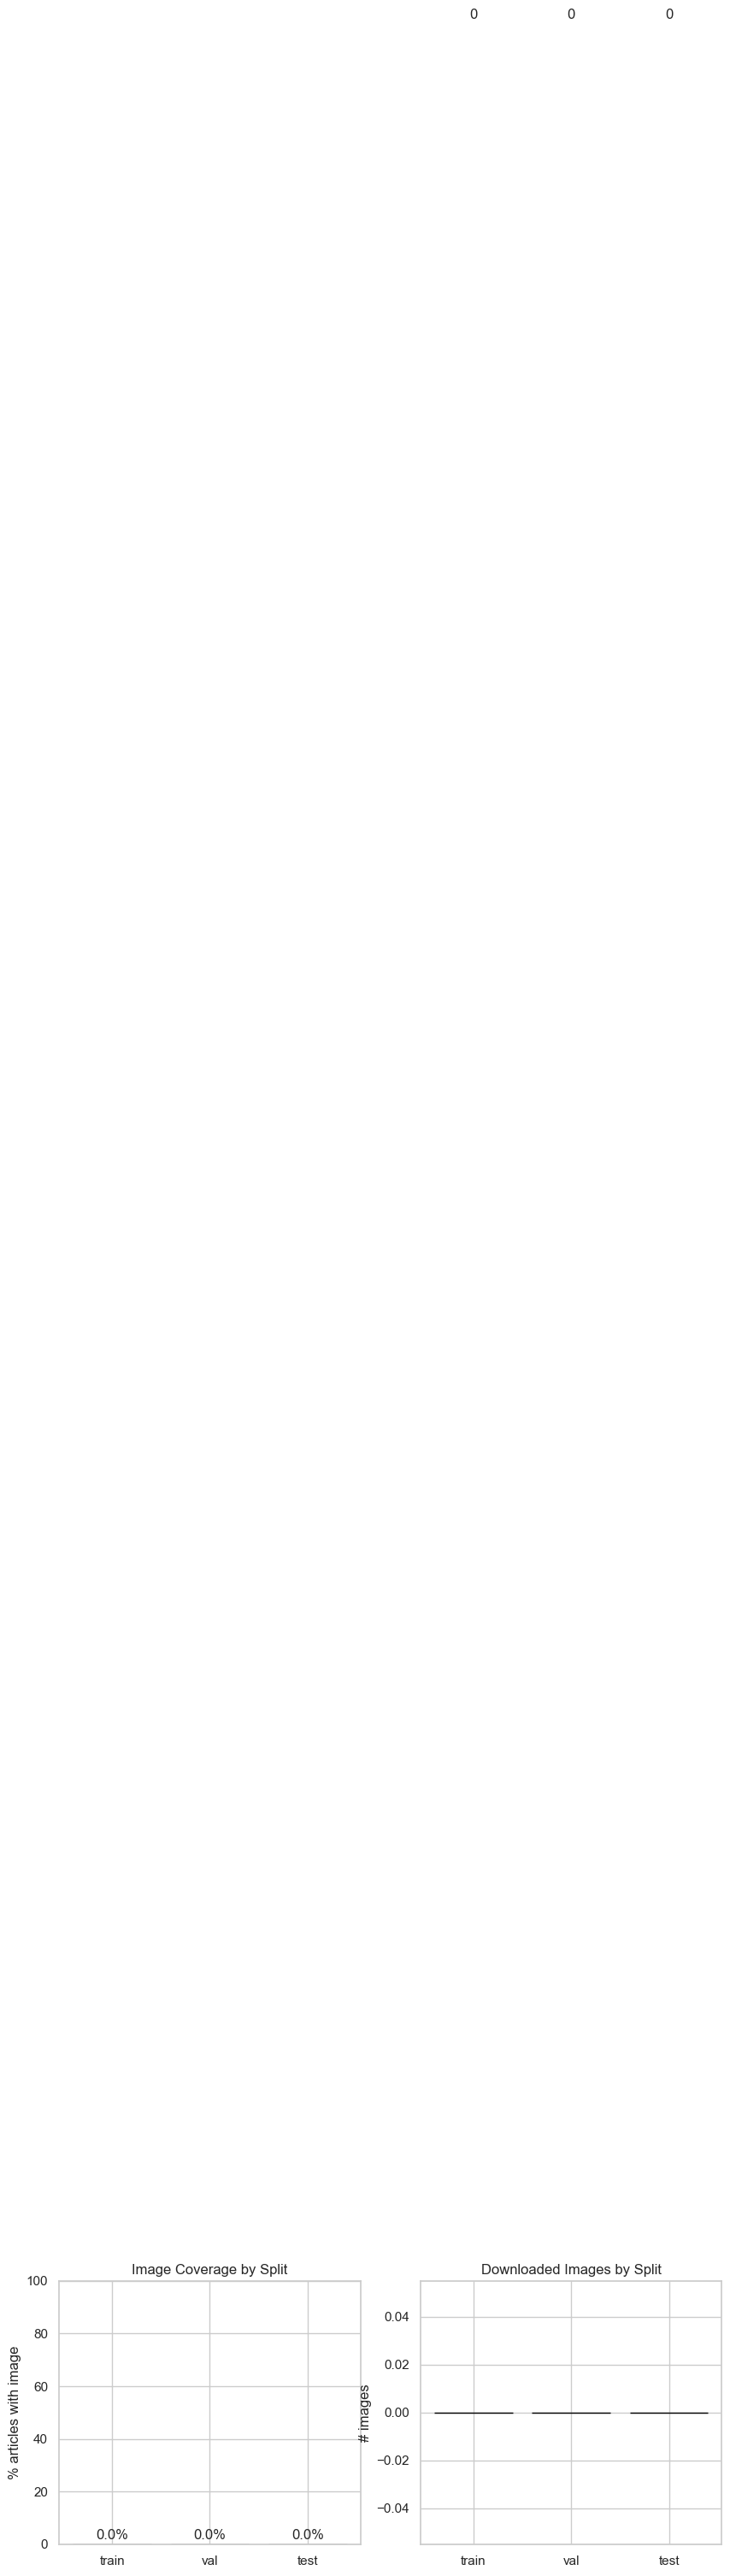

In [ ]:
stats_rows = []
for split_name, df in multimodal_splits.items():
    stats_rows.append({
        'split': split_name,
        'total_articles': len(df),
        'articles_with_images': int(df['has_image'].sum()),
        'image_coverage_%': 100 * df['has_image'].mean() if len(df) else 0,
        'total_images': int(df['n_images_downloaded'].sum()),
        'fake_with_images': int(((df['label'] == 'fake') & df['has_image']).sum()),
        'real_with_images': int(((df['label'] == 'real') & df['has_image']).sum()),
    })

coverage_df = pd.DataFrame(stats_rows)
display(coverage_df)
coverage_df.to_csv('ms1_image_coverage_summary.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(coverage_df['split'], coverage_df['image_coverage_%'], edgecolor='black')
axes[0].set_title('Image Coverage by Split')
axes[0].set_ylabel('% articles with image')
axes[0].set_ylim(0, 100)
for i, v in enumerate(coverage_df['image_coverage_%']):
    axes[0].text(i, min(v + 2, 98), f'{v:.1f}%', ha='center')

axes[1].bar(coverage_df['split'], coverage_df['total_images'], edgecolor='black')
axes[1].set_title('Downloaded Images by Split')
axes[1].set_ylabel('# images')
for i, v in enumerate(coverage_df['total_images']):
    axes[1].text(i, v + max(1, coverage_df['total_images'].max() * 0.03), str(v), ha='center')

plt.tight_layout()
plt.savefig('plot_image_download_stats_fixed.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8 · Report-Ready Summary

For the MS1 report, use the table and plot above to describe the **image pipeline readiness**:

- The notebook creates a direct mapping from each article ID to the downloaded image paths.
- If an article image is missing, the model notebook handles it with a neutral placeholder, so the pipeline remains reproducible.
- `*_multimodal.csv` files are the final output of this stage and are used by the text-only baseline and multimodal fusion model.
- Low image coverage should be reported as a project risk because it limits the model's ability to learn image--text inconsistency.
